MAE: 21215.991658556646
MSE: 656650349.2011747
R2 Score: 0.9266599332863692
RMSE: 25625.189739808266
location_score     14983.413235
bathrooms          11935.118621
bedrooms            9118.306593
square_footage       117.778570
house_age_years     -492.031361
dtype: float64
   square_footage  bedrooms  bathrooms  house_age_years  location_score   price
0            2133         3        4.0               12               5  468400
1            1736         3        3.5               48               4  381200
2            1682         2        3.0               36               4  341400
3            1682         3        3.5               42               3  292000
4            2980         5        5.0               38               6  552900
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   square_footage   1000 non-null   int64  
 1   bedroom

C:\Users\javeer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



-------- House Price Prediction --------
Square footage : 4538.0 sqft
Bedrooms       : 7.0
Bathrooms      : 2.0
House age      : 56.0 years
Location score : 8.0
Predicted price: 766,663.26


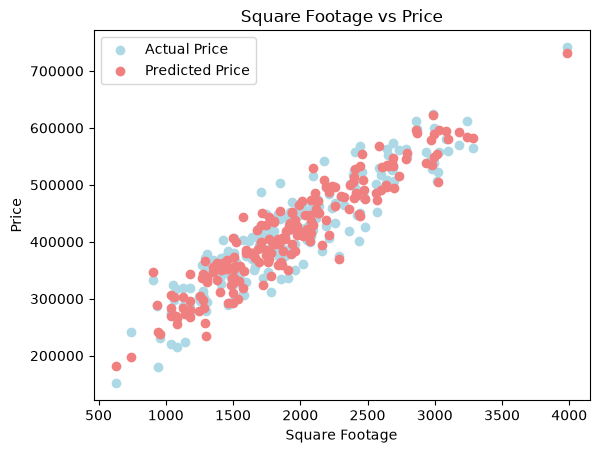

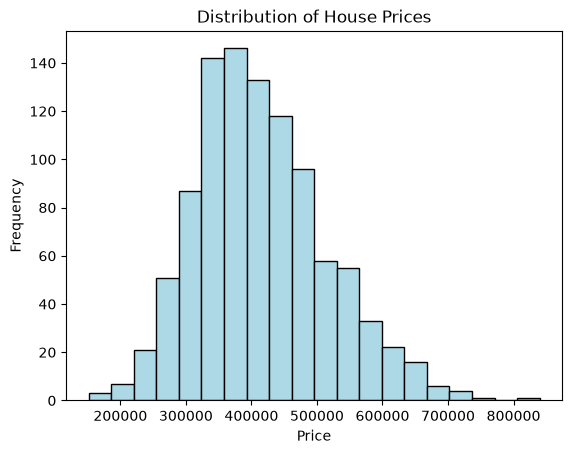

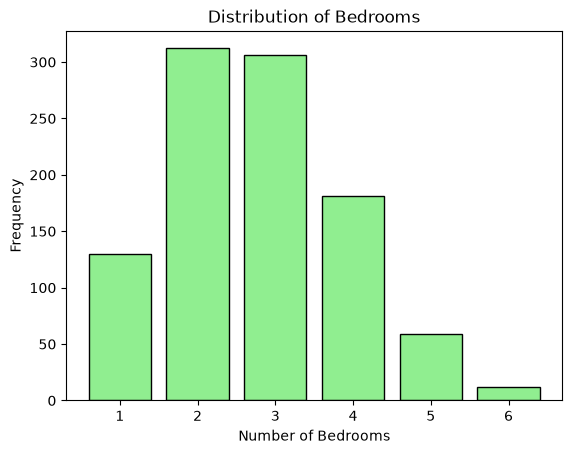

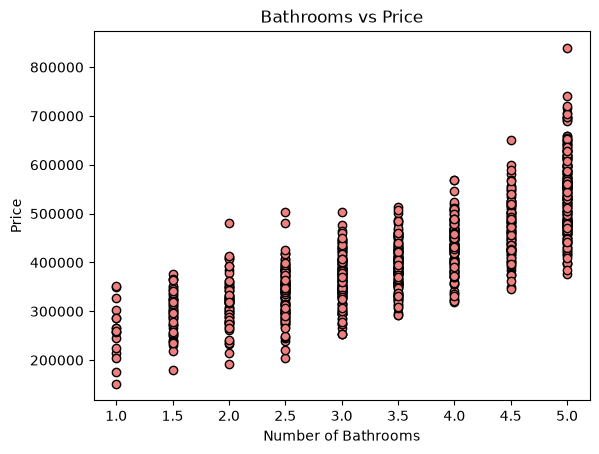

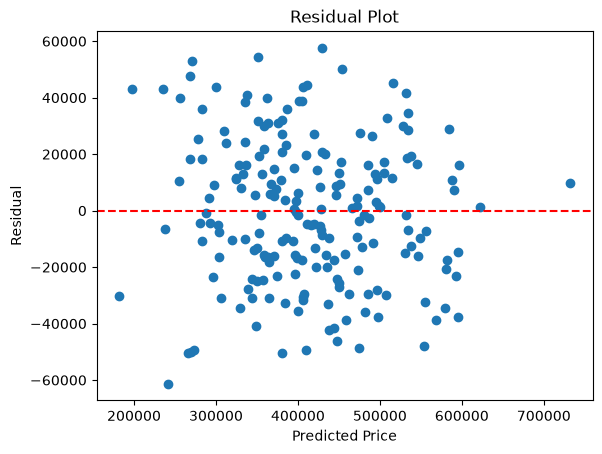

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression
data = pd.read_csv(r"c:\Users\javeer\Downloads\housing_price_dataset (1).csv")

x = data[["square_footage","bedrooms","bathrooms","house_age_years", "location_score"]]
y = data["price"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model =LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

coefficients = pd.Series(model.coef_, index=x_train.columns)
print(coefficients.sort_values(ascending=False))

print(data.head())
print(data.info())
print(data.describe())
print(data.isnull().sum())

square_footage = float(input("Enter how much your need area :"))
bedrooms = float(input("Enter the number of bedrooms :"))
bathrooms = float(input("Enter the number of bathrooms :"))
house_age_years = float(input("Enter the age of the house in years :"))
location_score = float(input("Enter the location score (0-10) :"))

predicted_price = model.predict([[square_footage, bedrooms, bathrooms, house_age_years, location_score]])

new_house = pd.DataFrame(
    [[square_footage, bedrooms, bathrooms, house_age_years, location_score]],
    columns=x_train.columns
)
 
predicted_price = model.predict(new_house)[0]
 
print("\n-------- House Price Prediction --------")
print(f"Square footage : {square_footage} sqft")
print(f"Bedrooms       : {bedrooms}")
print(f"Bathrooms      : {bathrooms}")
print(f"House age      : {house_age_years} years")
print(f"Location score : {location_score}")
print(f"Predicted price: {predicted_price:,.2f}")


# 1) Actual vs Predicted price (based on square footage)
plt.scatter(x_test["square_footage"], y_test, color='lightblue', label='Actual Price')
plt.scatter(x_test["square_footage"], y_pred, color='lightcoral', label='Predicted Price')
plt.xlabel("Square Footage")
plt.ylabel("Price")
plt.title("Square Footage vs Price")
plt.legend()
plt.show()

# 2) Distribution of house prices
price = data["price"]
plt.hist(price, bins=20, color='lightblue', edgecolor='black')
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

# 3) Distribution of bedrooms
plt.bar(data["bedrooms"].value_counts().index, data["bedrooms"].value_counts().values, color='lightgreen', edgecolor='black')
plt.xlabel("Number of Bedrooms")
plt.ylabel("Frequency")
plt.title("Distribution of Bedrooms")
plt.show()

# 4) Bathrooms vs Price
plt.scatter(data["bathrooms"], data["price"], color='lightcoral', edgecolor='black')
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price")
plt.title("Bathrooms vs Price")
plt.show()

# 5) Residual plot
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

